# FIFA World Cup 2026 — Predicted Results

Read-only view of outputs from `Fifa_worldcup2026_TournamentPrediction.ipynb`.

**Prerequisite:** run the tournament prediction notebook first so these files exist:

- `Data/fifa_worldcup_2026_predictions.csv` — group-stage scores
- `Data/fifa_worldcup_2026_group_tables.csv` — per-group standings
- `Data/fifa_worldcup_2026_standings.csv` — qualification summary
- `Data/predicted_tournament_results.csv` — knockout scores
- `Data/final_tournament_standings.csv` — elimination round per team

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from IPython.display import HTML, display

DATA = Path("Data")

group_predictions = pd.read_csv(DATA / "fifa_worldcup_2026_predictions.csv")
group_tables = pd.read_csv(DATA / "fifa_worldcup_2026_group_tables.csv")
qualification = pd.read_csv(DATA / "fifa_worldcup_2026_standings.csv")
knockout = pd.read_csv(DATA / "predicted_tournament_results.csv")
final_standings = pd.read_csv(DATA / "final_tournament_standings.csv")

KNOCKOUT_ROUND_ORDER = [
    "Round of 32",
    "Round of 16",
    "Quarterfinals",
    "Semifinals",
    "Third place",
    "Final",
]

BRACKET_FEEDERS = {
    90: (73, 75), 89: (74, 77), 91: (76, 78), 92: (79, 80),
    93: (83, 84), 94: (81, 82), 95: (86, 88), 96: (85, 87),
    97: (89, 90), 98: (93, 94), 99: (91, 92), 100: (95, 96),
    101: (97, 98), 102: (99, 100), 104: (101, 102),
}
R32_MATCHES = list(range(73, 89))

## Tournament outcome

In [2]:
def _team_at(position):
    rows = final_standings.loc[final_standings["Position"] == position, "Team"]
    return rows.iloc[0] if len(rows) else None


champion = _team_at("Champion")
runner_up = _team_at("Runner-up")
third = _team_at("Third place")
fourth = _team_at("Fourth place")

final_row = knockout.loc[knockout["Round"] == "Final"].iloc[0]
third_row = knockout.loc[knockout["Round"] == "Third place"]
third_score = ""
if len(third_row):
    t = third_row.iloc[0]
    third_score = (
        f" ({t['Team1']} {t['Predicted Goals Team1']:.0f}–"
        f"{t['Predicted Goals Team2']:.0f} {t['Team2']})"
    )

display(
    HTML(
        f"""
        <div style="font-family: system-ui, sans-serif; line-height: 1.6;">
          <p style="font-size: 1.4rem;">🏆 <strong>Champion:</strong> {champion}</p>
          <p><strong>Final:</strong> {final_row['Team1']}
             {final_row['Predicted Goals Team1']:.0f}–{final_row['Predicted Goals Team2']:.0f}
             {final_row['Team2']} → <em>{final_row['Winner']}</em></p>
          <p><strong>Runner-up:</strong> {runner_up}</p>
          <p><strong>Third place:</strong> {third}{third_score}</p>
          <p><strong>Fourth place:</strong> {fourth}</p>
        </div>
        """
    )
)

## Group stage — predicted matches

Scores are rounded integer goals from the Random Forest models.

In [3]:
def format_match_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Score"] = (
        out["PredictedHomeGoals"].astype(str) + "–" + out["PredictedAwayGoals"].astype(str)
    )
    return out.rename(columns={"score": "Fixture"})[
        ["Fixture", "HomeTeam", "Score", "AwayTeam", "Winner"]
    ]


team_to_group = group_tables.set_index("Team")["Group"].to_dict()
matches = group_predictions.copy()
matches["Group"] = matches.apply(
    lambda r: team_to_group.get(r["HomeTeam"]) or team_to_group.get(r["AwayTeam"]),
    axis=1,
)

for group in sorted(matches["Group"].dropna().unique()):
    group_matches = matches.loc[matches["Group"] == group].sort_values("score")
    print(f"\n{group} ({len(group_matches)} matches)")
    display(
        format_match_table(group_matches)
        .style.hide(axis="index")
        .set_properties(**{"text-align": "left"})
    )


Group A (6 matches)


Fixture,HomeTeam,Score,AwayTeam,Winner
Match 1,Mexico,1–1,South Africa,Draw
Match 2,South Korea,1–1,Czech Republic,Draw
Match 25,Czech Republic,1–1,South Africa,Draw
Match 28,Mexico,1–1,South Korea,Draw
Match 53,Czech Republic,1–1,Mexico,Draw
Match 54,South Africa,1–2,South Korea,South Korea



Group B (6 matches)


Fixture,HomeTeam,Score,AwayTeam,Winner
Match 26,Switzerland,2–1,Bosnia and Herzegovina,Switzerland
Match 27,Canada,2–1,Qatar,Canada
Match 3,Canada,1–1,Bosnia and Herzegovina,Draw
Match 51,Switzerland,2–1,Canada,Switzerland
Match 52,Bosnia and Herzegovina,2–1,Qatar,Bosnia and Herzegovina
Match 8,Qatar,1–2,Switzerland,Switzerland



Group C (6 matches)


...

Fixture,HomeTeam,Score,AwayTeam,Winner
Match 19,Argentina,1–1,Algeria,Draw
Match 20,Austria,2–1,Jordan,Austria
Match 43,Argentina,2–1,Austria,Argentina
Match 44,Jordan,1–2,Algeria,Algeria
Match 69,Algeria,1–1,Austria,Draw
Match 70,Jordan,1–2,Argentina,Argentina



Group K (6 matches)


Fixture,HomeTeam,Score,AwayTeam,Winner
Match 23,Portugal,2–1,DR Congo,Portugal
Match 24,Uzbekistan,1–2,Colombia,Colombia
Match 47,Portugal,3–1,Uzbekistan,Portugal
Match 48,Colombia,2–2,DR Congo,Draw
Match 71,Colombia,1–2,Portugal,Portugal
Match 72,DR Congo,2–1,Uzbekistan,DR Congo



Group L (6 matches)


Fixture,HomeTeam,Score,AwayTeam,Winner
Match 21,Ghana,2–1,Panama,Ghana
Match 22,England,2–1,Croatia,England
Match 45,England,2–1,Ghana,England
Match 46,Panama,1–2,Croatia,Croatia
Match 67,Panama,1–2,England,England
Match 68,Croatia,1–1,Ghana,Draw


## Group standings & qualification

In [4]:
for group in sorted(group_tables["Group"].unique()):
    table = group_tables.loc[group_tables["Group"] == group].copy()
    table["Status"] = table["Team"].map(
        qualification.set_index("Team")["QualificationRoute"]
    )
    print(f"\n{group}")
    display(
        table[["Team", "Points", "GF", "GA", "GD", "GroupRank", "Status"]]
        .style.hide(axis="index")
        .format({"Points": "{:.0f}", "GF": "{:.0f}", "GA": "{:.0f}", "GD": "{:+.0f}"})
        .set_properties(**{"text-align": "left"})
    )

print(f"\n{qualification['Qualified'].sum()} teams qualified for the Round of 32.")


Group A


Team,Points,GF,GA,GD,GroupRank,Status
South Korea,5,4,3,+1,1,Top 1 in Group A
Czech Republic,3,3,3,+0,2,Top 2 in Group A
Mexico,3,3,3,+0,3,Best third-placed (#8)
South Africa,2,3,4,-1,4,Eliminated in group stage



Group B


Team,Points,GF,GA,GD,GroupRank,Status
Switzerland,9,6,3,+3,1,Top 1 in Group B
Bosnia and Herzegovina,4,4,4,+0,2,Top 2 in Group B
Canada,4,4,4,+0,3,Best third-placed (#4)
Qatar,0,3,6,-3,4,Eliminated in group stage



Group C


...


Group K


Team,Points,GF,GA,GD,GroupRank,Status
Portugal,9,7,3,+4,1,Top 1 in Group K
Colombia,4,5,5,+0,2,Top 2 in Group K
DR Congo,4,5,5,+0,3,Best third-placed (#1)
Uzbekistan,0,3,7,-4,4,Eliminated in group stage



Group L


Team,Points,GF,GA,GD,GroupRank,Status
England,9,6,3,+3,1,Top 1 in Group L
Croatia,4,4,4,+0,2,Top 2 in Group L
Ghana,4,4,4,+0,3,Best third-placed (#7)
Panama,0,3,6,-3,4,Eliminated in group stage



32 teams qualified for the Round of 32.


## Knockout stage — match list

In [5]:
def format_knockout_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Score"] = (
        out["Predicted Goals Team1"].round(1).astype(str)
        + "–"
        + out["Predicted Goals Team2"].round(1).astype(str)
    )
    return out[["Match", "Team1", "Score", "Team2", "Winner"]]


for round_name in KNOCKOUT_ROUND_ORDER:
    round_matches = knockout.loc[knockout["Round"] == round_name].sort_values("Match")
    if round_matches.empty:
        continue
    print(f"\n{round_name} ({len(round_matches)} matches)")
    display(
        format_knockout_table(round_matches)
        .style.hide(axis="index")
        .set_properties(**{"text-align": "left"})
    )


Round of 32 (16 matches)


Match,Team1,Score,Team2,Winner
73,Czech Republic,1.8–1.4,Bosnia and Herzegovina,Czech Republic
74,Germany,2.4–0.9,Canada,Germany
75,Netherlands,1.8–1.1,Morocco,Netherlands
76,Brazil,1.8–1.3,Japan,Brazil
77,France,1.5–0.8,Sweden,France
78,Ecuador,1.2–1.5,Norway,Norway
79,South Korea,1.0–1.4,Senegal,Senegal
80,England,2.5–1.0,DR Congo,England
81,United States,1.3–1.2,Austria,United States
82,Belgium,1.9–0.9,Mexico,Belgium



Round of 16 (8 matches)


Match,Team1,Score,Team2,Winner
89,Germany,1.4–1.4,France,France
90,Czech Republic,0.7–0.9,Netherlands,Netherlands
91,Brazil,2.0–0.9,Norway,Brazil
92,Senegal,1.5–1.1,England,Senegal
93,Croatia,0.9–1.0,Spain,Spain
94,United States,1.0–1.8,Belgium,Belgium
95,Argentina,1.9–0.8,Turkey,Argentina
96,Ivory Coast,0.9–1.0,Portugal,Portugal



Quarterfinals (4 matches)


...

Match,Team1,Score,Team2,Winner
101,France,1.3–1.2,Spain,France
102,Brazil,1.4–1.1,Portugal,Brazil



Third place (1 matches)


Match,Team1,Score,Team2,Winner
103,Spain,1.9–0.8,Portugal,Spain



Final (1 matches)


Match,Team1,Score,Team2,Winner
104,France,2.0–1.1,Brazil,France


## Knockout bracket (graphic)

Left-to-right bracket using the official match wiring from the scraped fixture list. Third-place match shown below the final.

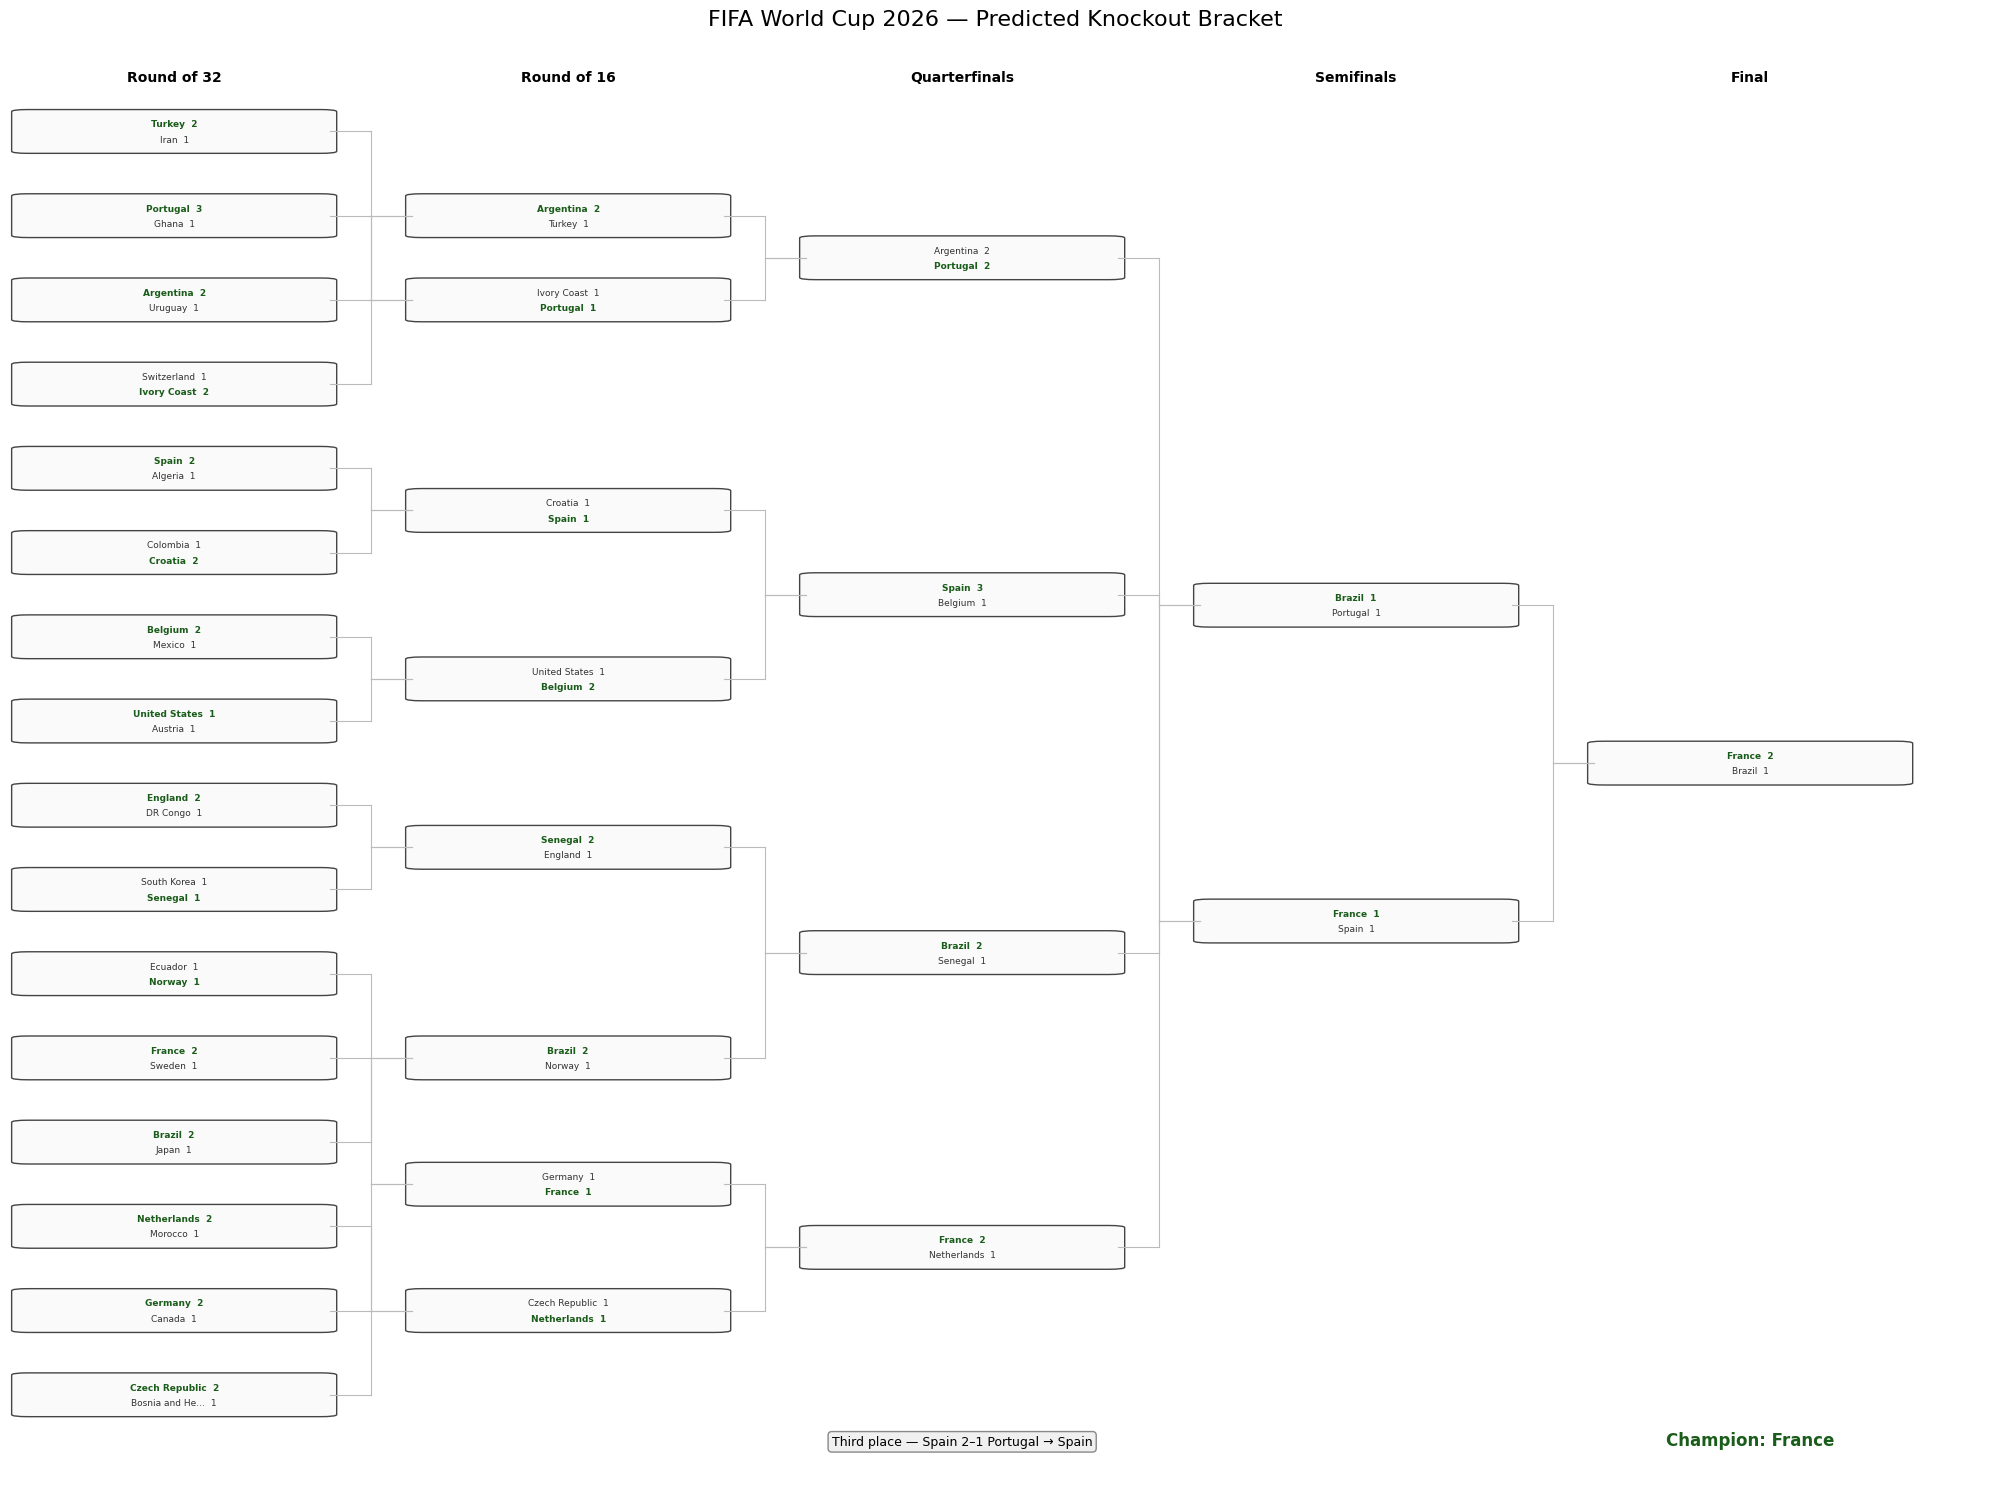

In [6]:
def _bracket_y_positions() -> dict[int, float]:
    y = {m: i * 2.0 for i, m in enumerate(R32_MATCHES)}
    for matches in (
        [90, 89, 91, 92, 93, 94, 95, 96],
        [97, 98, 99, 100],
        [101, 102],
        [104],
    ):
        for match_no in matches:
            a, b = BRACKET_FEEDERS[match_no]
            y[match_no] = (y[a] + y[b]) / 2.0
    return y


def _short_name(name: str, max_len: int = 14) -> str:
    return name if len(name) <= max_len else name[: max_len - 1] + "…"


def _draw_match_box(ax, x: float, y: float, row: pd.Series, box_w: float, box_h: float) -> None:
    t1, t2, winner = row["Team1"], row["Team2"], row["Winner"]
    g1, g2 = row["Predicted Goals Team1"], row["Predicted Goals Team2"]
    rect = mpatches.FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.02,rounding_size=0.05",
        linewidth=1,
        edgecolor="#444",
        facecolor="#fafafa",
    )
    ax.add_patch(rect)
    line1 = f"{_short_name(t1)}  {g1:.0f}"
    line2 = f"{_short_name(t2)}  {g2:.0f}"
    ax.text(x, y + 0.18, line1, ha="center", va="center", fontsize=6.5,
            fontweight="bold" if t1 == winner else "normal", color="#1a5c1a" if t1 == winner else "#333")
    ax.text(x, y - 0.18, line2, ha="center", va="center", fontsize=6.5,
            fontweight="bold" if t2 == winner else "normal", color="#1a5c1a" if t2 == winner else "#333")


def draw_knockout_bracket(knockout_df: pd.DataFrame) -> None:
    results = {int(r["Match"]): r for _, r in knockout_df.iterrows()}
    y_pos = _bracket_y_positions()

    rounds = [
        ("Round of 32", R32_MATCHES, 0),
        ("Round of 16", [90, 89, 91, 92, 93, 94, 95, 96], 1),
        ("Quarterfinals", [97, 98, 99, 100], 2),
        ("Semifinals", [101, 102], 3),
        ("Final", [104], 4),
    ]

    fig, ax = plt.subplots(figsize=(20, 15))
    ax.set_xlim(-0.5, 5.5)
    ax.set_ylim(-2, max(y_pos.values()) + 2)
    ax.axis("off")
    ax.set_title("FIFA World Cup 2026 — Predicted Knockout Bracket", fontsize=16, pad=16)

    box_w, box_h = 0.95, 1.0
    x_cols = [0, 1.2, 2.4, 3.6, 4.8]

    for label, match_ids, col in rounds:
        ax.text(x_cols[col], max(y_pos.values()) + 1.2, label, ha="center", fontsize=10, fontweight="bold")
        for match_no in match_ids:
            if match_no not in results:
                continue
            row = results[match_no]
            x, y = x_cols[col], y_pos[match_no]
            _draw_match_box(ax, x, y, row, box_w, box_h)

            if match_no in BRACKET_FEEDERS and col > 0:
                a, b = BRACKET_FEEDERS[match_no]
                x_prev = x_cols[col - 1]
                mid_x = (x_prev + box_w / 2 + x - box_w / 2) / 2
                for feeder in (a, b):
                    if feeder not in y_pos:
                        continue
                    y_feed = y_pos[feeder]
                    ax.plot([x_prev + box_w / 2, mid_x], [y_feed, y_feed], color="#bbb", linewidth=0.8)
                    ax.plot([mid_x, mid_x], [y_feed, y], color="#bbb", linewidth=0.8)
                    ax.plot([mid_x, x - box_w / 2], [y, y], color="#bbb", linewidth=0.8)

    if 103 in results:
        t = results[103]
        label = (
            f"Third place — {t['Team1']} {t['Predicted Goals Team1']:.0f}–"
            f"{t['Predicted Goals Team2']:.0f} {t['Team2']} → {t['Winner']}"
        )
        ax.text(2.4, -1.2, label, ha="center", fontsize=9,
                bbox=dict(boxstyle="round", facecolor="#f0f0f0", edgecolor="#888"))

    if 104 in results:
        champ = results[104]["Winner"]
        ax.text(4.8, -1.2, f"Champion: {champ}", ha="center", fontsize=12, fontweight="bold", color="#1a5c1a")

    plt.tight_layout()
    plt.show()


draw_knockout_bracket(knockout)